# Imputation

In [81]:
import pandas as pd
from taxipred.utils.constants import TAXI_CSV_PATH
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(TAXI_CSV_PATH)

I will be applying different imputation methods on the numerical columns to see which one fits better for a normal distribution. 

In [82]:
# Splitting columns based on numerical and categorical columns
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(exclude="number").columns

## Mean Imputation
- This method involves replacing missing values with the meanof the relevant variable. It's a simple approach but it doesn't account for the relationships between variables.

In [83]:
df_mean = df.copy()
for col in num_cols:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())

Text(0.5, 1.0, 'Mean Imputed Distribution of Trip Price')

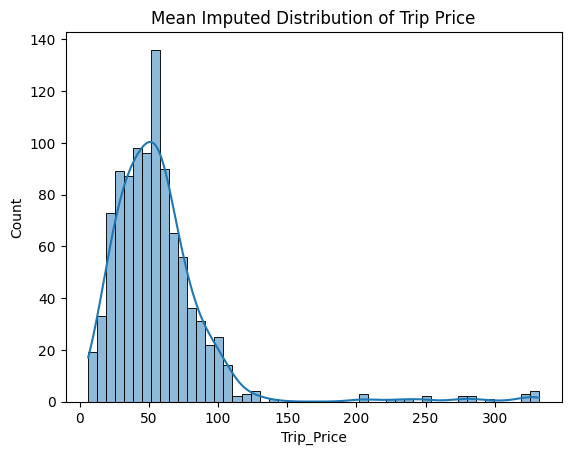

In [84]:
sns.histplot(df_mean["Trip_Price"], kde=True)
plt.title("Mean Imputed Distribution of Trip Price")

Text(0.5, 1.0, 'Correlation Matrix for Mean Imputated Data')

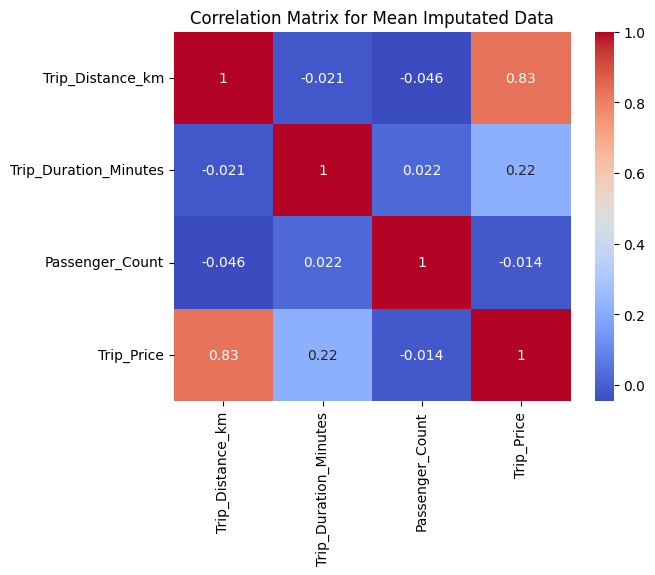

In [85]:
corr_cols = [
    "Trip_Distance_km",
    "Trip_Duration_Minutes",
    "Passenger_Count",
    "Trip_Price"
]

sns.heatmap(df_mean[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix for Mean Imputated Data")

In [86]:
percentiles = [0.1, 0.25, 0.5, 0.75, 0.9]
df_mean[num_cols].quantile(percentiles)


,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0.10,5.8620,1.000000,2.320000,0.650000,0.140000,17.938000,23.35343
0.25,13.1075,2.000000,2.770000,0.870000,0.197500,37.107500,34.57885
0.50,26.9950,2.476842,3.502989,1.233316,0.292916,62.118116,52.61700
0.75,37.7825,3.000000,4.202500,1.580000,0.382500,87.775000,67.47665
0.90,45.6510,4.000000,4.720000,1.850000,0.450000,106.428000,88.13414


## Linear Imputation

- Pros: captures trends, preserves relationships
- Cons: assumes a pattern (linear) may be complex

In [87]:
df_linear = df.copy()
df_linear[num_cols] = df_linear[num_cols].interpolate(method="linear")

Text(0.5, 1.0, 'Linear Imputed Distribution of Trip Price')

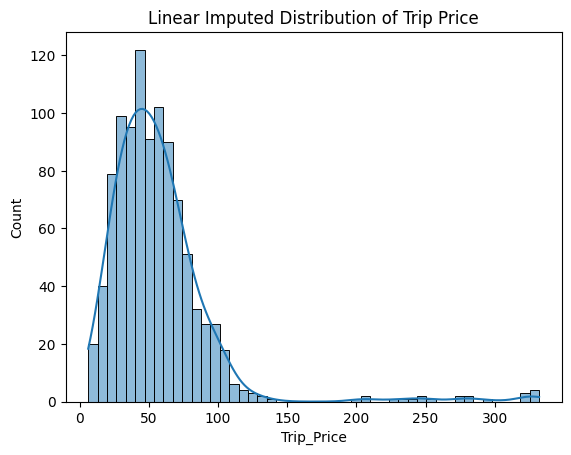

In [88]:
sns.histplot(df_linear["Trip_Price"], kde=True)
plt.title("Linear Imputed Distribution of Trip Price")

Text(0.5, 1.0, 'Correlation Matrix for Linear Imputated Data')

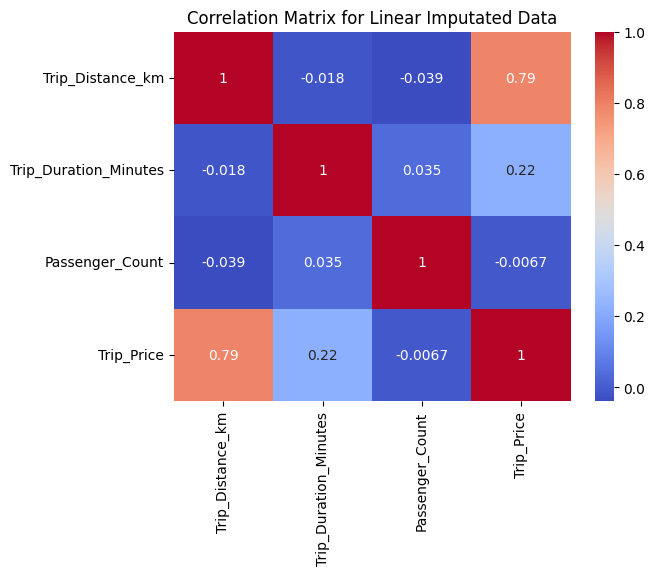

In [89]:
sns.heatmap(df_linear[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix for Linear Imputated Data")

In [90]:
df_linear.describe().loc[['mean', '25%', '50%', '75%', 'max', 'min']]

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
mean,27.193986,2.481,3.503245,1.235815,0.2926,62.27556,56.885057
25%,12.875000,2.000,2.760000,0.870000,0.1900,36.54500,34.342400
50%,25.775000,2.500,3.510000,1.220000,0.2900,62.01500,50.372500
75%,38.330000,3.000,4.230000,1.610000,0.3900,88.23500,68.937550
max,146.067047,4.000,5.000000,2.000000,0.5000,119.84000,332.043689
min,1.230000,1.000,2.010000,0.500000,0.1000,5.01000,6.126900


## MICE Imputation
- MICE (Multiple Imputation by Chained Equations) is
a powerful statistical method for handling missing data by creating multiple complete datasets, rather than just one, to better reflect the uncertainty and preserve relationships within the data, making analyses more robust and reliable

In [91]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df_mice = df.copy()
mice_imputer = IterativeImputer(random_state=42)
df_mice[num_cols] = mice_imputer.fit_transform(df_mice[num_cols])

Text(0.5, 1.0, 'MICE Imputed Distribution of Trip Price')

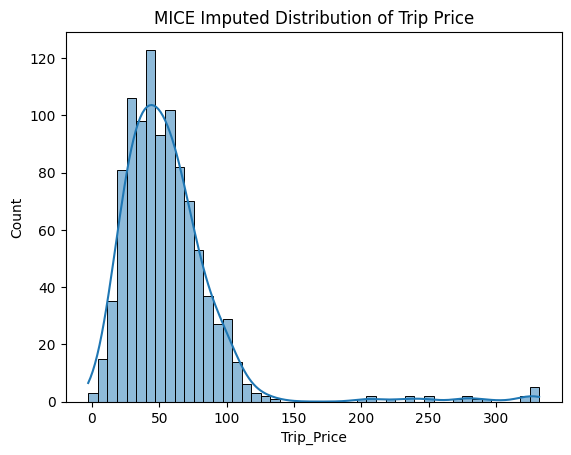

In [92]:
sns.histplot(df_mice["Trip_Price"], kde=True)
plt.title("MICE Imputed Distribution of Trip Price")

Text(0.5, 1.0, 'Correlation Matrix for MICE Imputated Data')

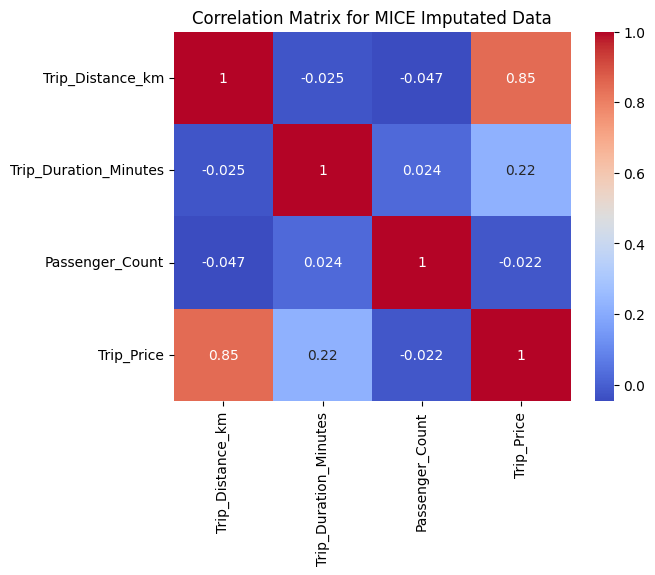

In [93]:
sns.heatmap(df_mice[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix for MICE Imputated Data")

# Comparison

## Distribution Comparison
- After imputation, what does the FULL column distribution look like?

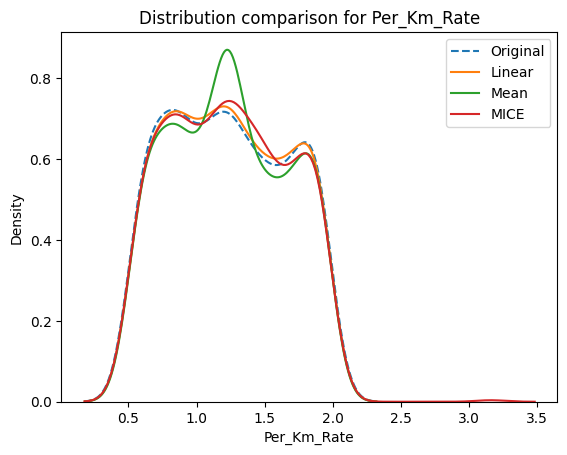

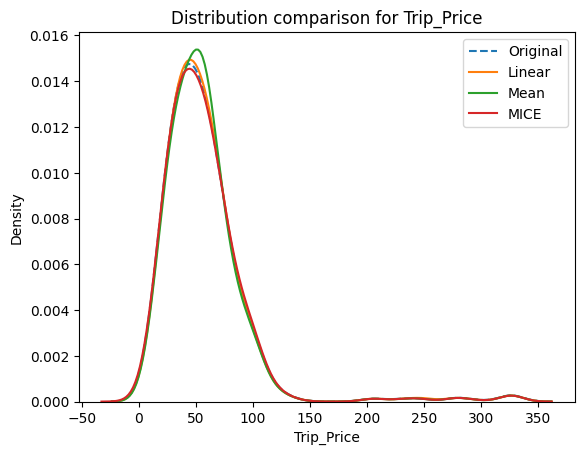

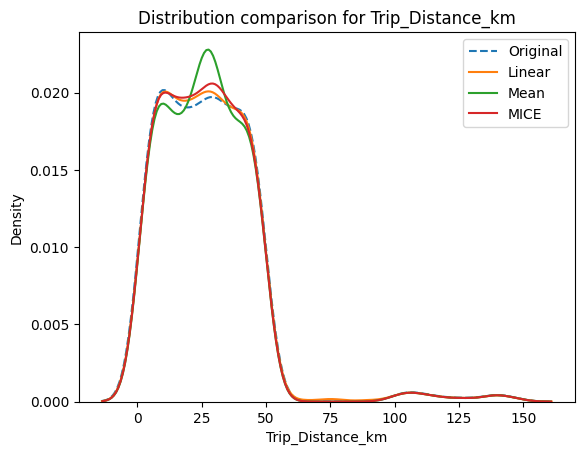

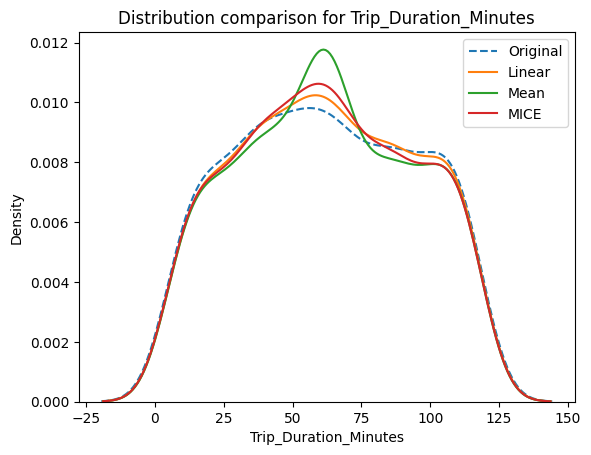

In [94]:
cols_to_check = [
    "Per_Km_Rate",
    "Trip_Price",
    "Trip_Distance_km",
    "Trip_Duration_Minutes",
]

for col in cols_to_check:
    plt.figure()

    sns.kdeplot(df[col], label="Original", linestyle="--")
    sns.kdeplot(df_linear[col], label="Linear")
    sns.kdeplot(df_mean[col], label="Mean")
    sns.kdeplot(df_mice[col], label="MICE")
    
    plt.legend()
    plt.title(f"Distribution comparison for {col}")

## Comparison over NaN Values
- What values did each imputation method invent where data was missing?

<!-- # Comparison based on NaN's
- What values did each imputation method invent where data was missing -->

/tmp/ipykernel_16384/2587225525.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


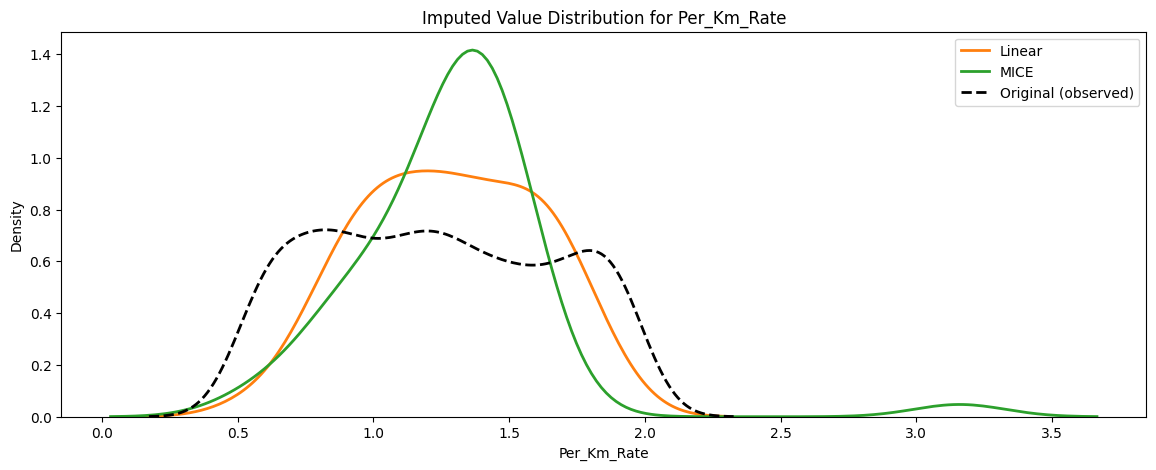

/tmp/ipykernel_16384/2587225525.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


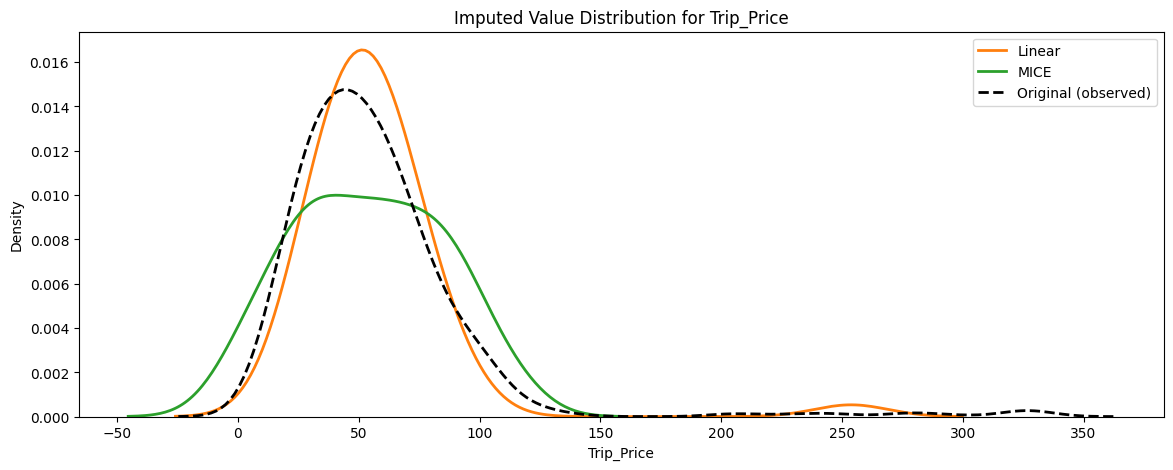

/tmp/ipykernel_16384/2587225525.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


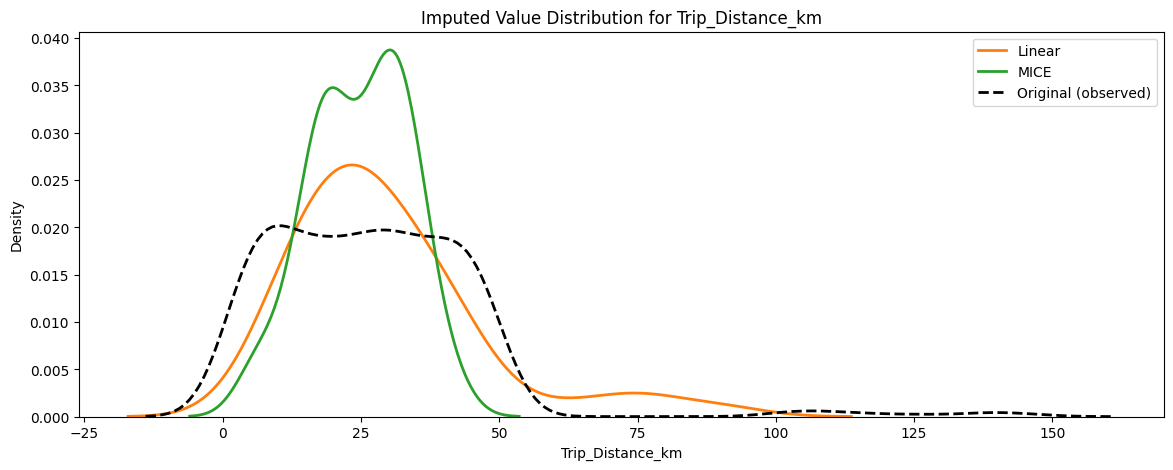

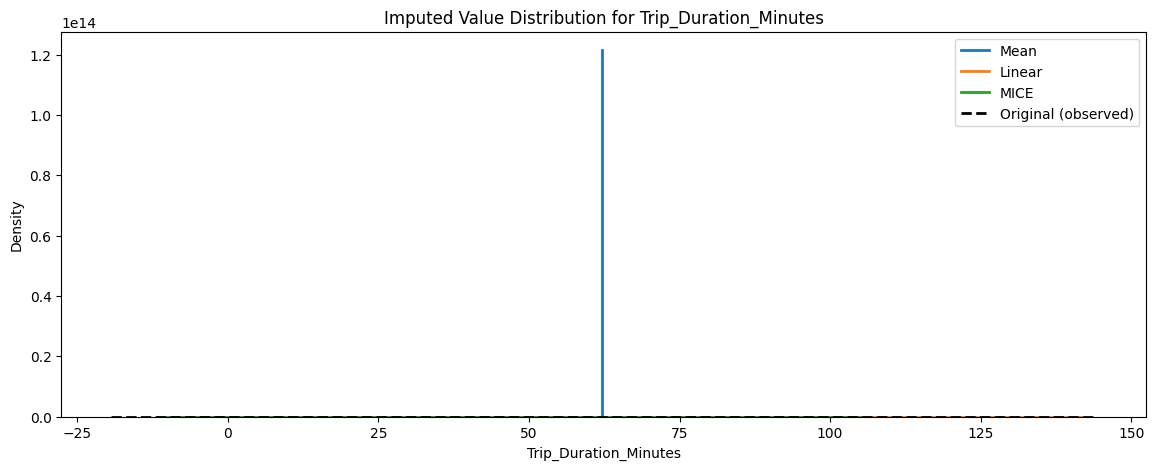

In [102]:
for col in cols_to_check:
    missing_mask = df[col].isna()

    # Skip columns with no missing values
    if missing_mask.sum() == 0:
        print(f"{col}: no missing values, skipping.")
        continue

    plt.figure(figsize=(14, 5))

    sns.kdeplot(
        df_mean.loc[missing_mask, col],
        label="Mean",
        linewidth=2
    )
    sns.kdeplot(
        df_linear.loc[missing_mask, col],
        label="Linear",
        linewidth=2
    )
    sns.kdeplot(
        df_mice.loc[missing_mask, col],
        label="MICE",
        linewidth=2
    )

    # Reference: observed (non-missing) values
    sns.kdeplot(
        df.loc[~missing_mask, col],
        label="Original (observed)",
        color="black",
        linestyle="--",
        linewidth=2
    )

    plt.title(f"Imputed Value Distribution for {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()
